In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e4/sample_submission.csv
/kaggle/input/playground-series-s5e4/train.csv
/kaggle/input/playground-series-s5e4/test.csv


In [2]:
train = pd.read_csv("../input/playground-series-s5e4/train.csv")
test = pd.read_csv("../input/playground-series-s5e4/test.csv")

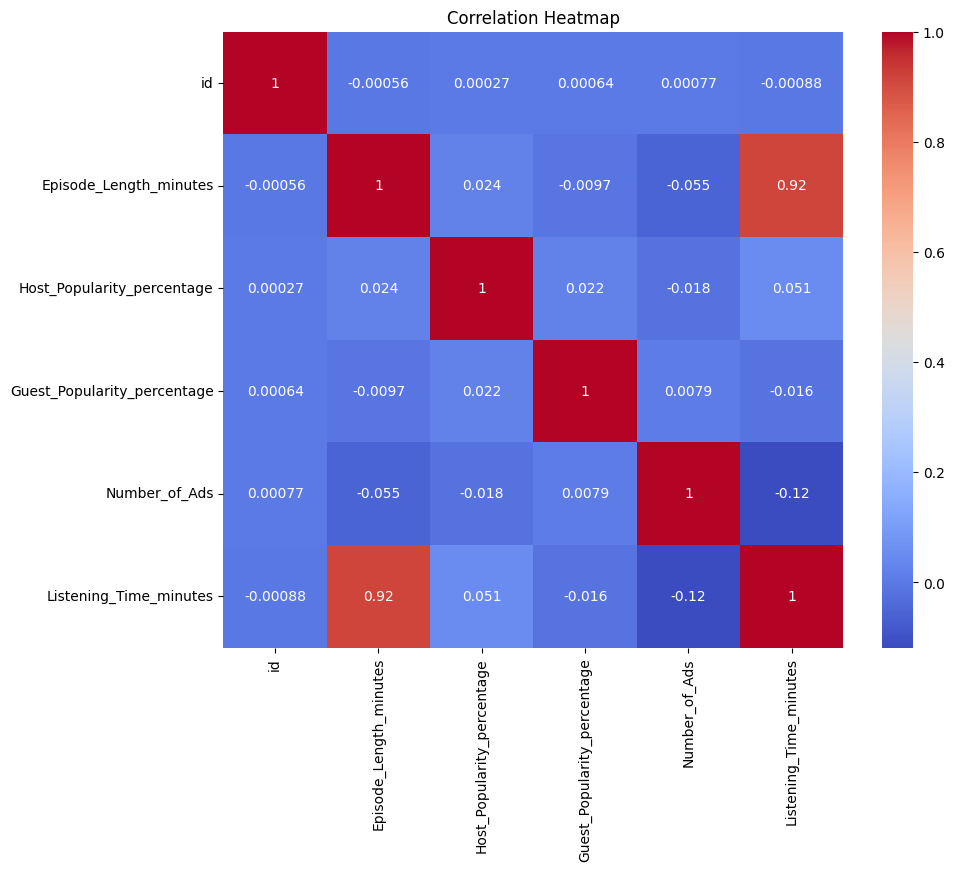

In [3]:
# ------------------------------------------------------------
# Exploratory Data Analysis (EDA)
# ------------------------------------------------------------

# Visualize correlation between numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(train.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

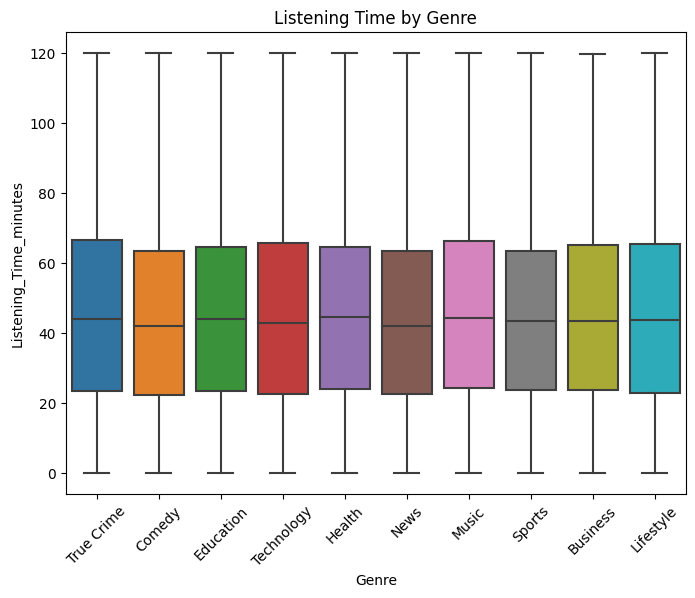

In [4]:
# Visualize target distribution by categorical variable
plt.figure(figsize=(8, 6))
sns.boxplot(x="Genre", y="Listening_Time_minutes", data=train)
plt.xticks(rotation=45)
plt.title("Listening Time by Genre")
plt.show()

In [5]:
# ------------------------------------------------------------
# Define preprocessing function for consistent feature processing
# ------------------------------------------------------------
def preprocess(df, medians=None, is_train=True):
    df = df.copy()

    # Fill missing values
    if medians is None and is_train:
        medians = {
            "Episode_Length_minutes": df["Episode_Length_minutes"].median(),
            "Guest_Popularity_percentage": df["Guest_Popularity_percentage"].median(),
            "Number_of_Ads": df["Number_of_Ads"].median(),
        }

    df["Episode_Length_minutes"] = df["Episode_Length_minutes"].fillna(
        medians["Episode_Length_minutes"]
    )
    df["Guest_Popularity_percentage"] = df["Guest_Popularity_percentage"].fillna(
        medians["Guest_Popularity_percentage"]
    )
    df["Number_of_Ads"] = df["Number_of_Ads"].fillna(medians["Number_of_Ads"])

    # Create new feature: popularity difference
    df["popularity_diff"] = (
        df["Host_Popularity_percentage"] - df["Guest_Popularity_percentage"]
    )

    # Create time period feature from publication time
    def get_time_period(time_str):
        try:
            if pd.isnull(time_str):
                return "unknown"
            h = int(time_str.split(":")[0])
            return "morning" if h < 12 else "afternoon" if h < 18 else "evening"
        except:
            return "unknown"

    df["Time_Period"] = df["Publication_Time"].apply(get_time_period)

    return df, medians

In [6]:
# Apply preprocessing to train and test
train, medians = preprocess(train, is_train=True)
test, _ = preprocess(test, medians, is_train=False)

In [7]:
# Separate target variable and drop unused columns
y = train["Listening_Time_minutes"]
X = train.drop(columns=["Listening_Time_minutes", "id"])
test_ids = test["id"]
test = test.drop(columns=["id"])

In [8]:
# Concatenate train and test for consistent encoding
combined = pd.concat([X, test], axis=0)
combined = pd.get_dummies(combined)

In [9]:
# Split back to train and test
X = combined[: len(X)]
X_test = combined[len(X) :]

In [10]:
# ------------------------------------------------------------
# Model Training with Cross Validation
# ------------------------------------------------------------

# Define LightGBM model
model = LGBMRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [11]:
# Evaluate with 5-fold cross validation
cv_scores = cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=5)
print("Cross-Validation RMSE Scores:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 177
[LightGBM] [Info] Start training from score 45.431997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 177
[LightGBM] [Info] Start training from score 45.422466
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead

In [12]:
# ------------------------------------------------------------
# Final Train/Test Split and Evaluation
# ------------------------------------------------------------

# Split training set into training and validation subsets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Train the model
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 177
[LightGBM] [Info] Start training from score 45.447808


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=500, random_state=42, subsample=0.8)

In [14]:
# Evaluate on validation set
y_pred = model.predict(X_valid)
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred)

In [15]:
# Output validation results
print("Validation Results:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Validation Results:
MSE: 169.98
RMSE: 13.04
R2 Score: 0.7690


In [16]:
# Generate predictions on test data
final_preds = model.predict(X_test)

In [17]:
# Create submission DataFrame
submission = pd.DataFrame({"id": test_ids, "Listening_Time_minutes": final_preds})

In [18]:
# Save submission file
submission.to_csv("submission_3.csv", index=False)

In [21]:
# Get feature importances and sort
feature_names = X.columns
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]  # descending order

# Select top N features (e.g., 20)
top_n = 20
top_features = [feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

In [22]:
# Select top N features (e.g., 20)
top_n = 20
top_features = [feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

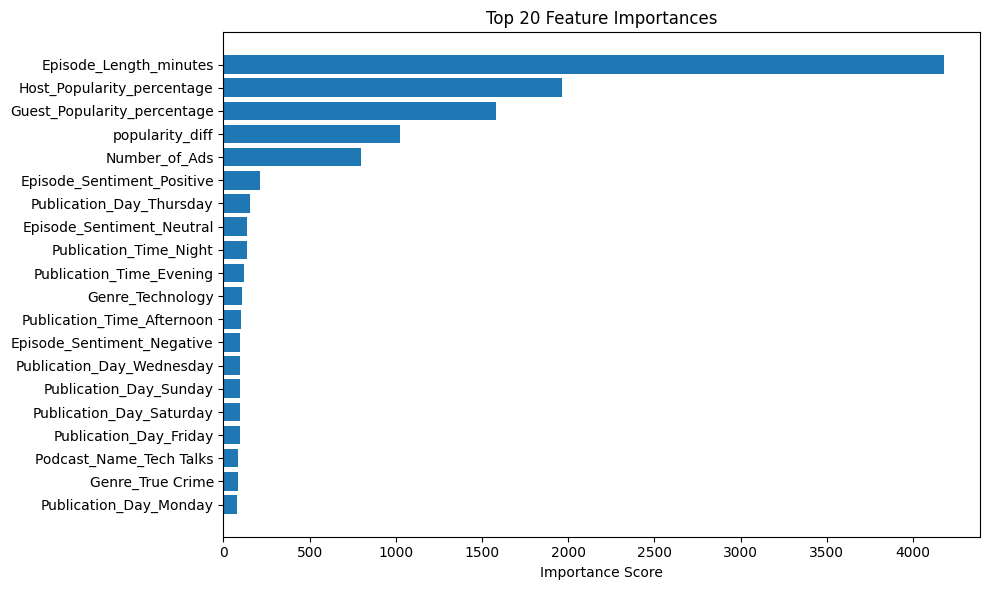

In [23]:
# Plot
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.barh(range(top_n), top_importances[::-1], align="center")  # horizontal bar chart
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()